# Addition Technologies Pvt Ltd – Self-Serve Kiosk Sales Dashboards

**Analysis Period:** October 2025 – December 2025  
**Clients:** Veena Stores | Rameshwaram Cafe | Asha Sweets | Bigbyte  
**Location:** Bangalore

## Dashboards
| # | Title | Output File |
|---|-------|-------------|
| **Dashboard 1** | Kiosk Sales Analytics – Food Item Revenue of All Clients/Restaurants (Oct–Dec 2025) | `dashboard1_complete.png` |
| **Dashboard 2** | Sales Comparison of All 4 Clients (Oct–Dec 2025) | `dashboard2_complete.png` |

> Each dashboard is a **single composite image**: highly-visible title banner + KPI cards + all charts together.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Rectangle
import warnings
warnings.filterwarnings('ignore')

# ── Brand config ──────────────────────────────────────────────────────
REST_ORDER  = ['Veena Stores', 'Rameshwaram Cafe', 'Asha Sweets', 'Bigbyte']
REST_COLORS = {
    'Veena Stores':     '#1565C0',
    'Rameshwaram Cafe': '#2E7D32',
    'Asha Sweets':      '#7B1FA2',
    'Bigbyte':          '#E65100',
}
MONTHS_ORDER = ['October 2025', 'November 2025', 'December 2025']
MONTHS_SHORT = ['Oct 2025', 'Nov 2025', 'Dec 2025']
BRAND_BG    = '#000000'   # pure black title/footer background
SUBTITLE_BG = '#1A1A1A'  # near-black subtitle bar
GOLD        = '#FFD700'
DASH_BG     = '#F0F4FF'

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.grid': True, 'grid.color': '#CCCCCC',
    'grid.linestyle': '--', 'grid.alpha': 0.25,
    'axes.edgecolor': '#BBBBBB', 'axes.facecolor': '#FFFFFF',
})
print('Setup complete.')

Setup complete.


In [2]:
df = pd.read_csv('Self_Serve_Kiosks_Sales_Data.csv', parse_dates=['Date'])
df['Month'] = pd.Categorical(df['Month'], categories=MONTHS_ORDER, ordered=True)

print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')
print(f'Date range: {df.Date.min().date()} → {df.Date.max().date()}')
print('Nulls:', df.isnull().sum().sum())
print('\nRevenue ranking (Veena → Rameshwaram → Asha → Bigbyte):')
print(df.groupby('Restaurant')['Net_Sales'].sum()
        .reindex(REST_ORDER).map('₹{:,.0f}'.format))
df.head(3)

Rows: 136,804  |  Columns: 21
Date range: 2025-10-01 → 2025-12-31
Nulls: 0

Revenue ranking (Veena → Rameshwaram → Asha → Bigbyte):
Restaurant
Veena Stores        ₹3,612,578
Rameshwaram Cafe    ₹3,179,052
Asha Sweets         ₹2,425,734
Bigbyte             ₹1,571,108
Name: Net_Sales, dtype: str


,Transaction_ID,Date,Month,Month_Num,Year,Day_of_Week,Order_DateTime,Restaurant,Kiosk_ID,Customer_ID,...,Category,Unit_Price,Quantity,Total_Sales,Discount,Net_Sales,Payment_Mode,City,Is_Weekend,Is_Festival_Day
0,TXN-000001,2025-10-01,October 2025,10,2025,Wednesday,2025-10-01 20:56,Veena Stores,KIOSK-VEE-02,CUST-VEE-20251001-0001,...,South Indian,75,1,75,0.00,75.00,Card,Bangalore,False,False
1,TXN-000002,2025-10-01,October 2025,10,2025,Wednesday,2025-10-01 20:56,Veena Stores,KIOSK-VEE-02,CUST-VEE-20251001-0001,...,South Indian,40,1,40,0.00,40.00,Card,Bangalore,False,False
2,TXN-000003,2025-10-01,October 2025,10,2025,Wednesday,2025-10-01 08:11,Veena Stores,KIOSK-VEE-02,CUST-VEE-20251001-0002,...,South Indian,75,1,75,3.75,71.25,UPI,Bangalore,False,False


In [3]:
def draw_title_banner(fig, title_text, subtitle_text,
                      y_top=0.940, title_h=0.062, sub_h=0.028):
    """
    Draws a solid black title banner using figure-level Rectangle patches
    and fig.text() — guarantees correct rendering in saved PNG files.
    """
    # Black title bar
    fig.patches.append(Rectangle(
        (0, y_top), 1.0, title_h,
        transform=fig.transFigure,
        facecolor=BRAND_BG, edgecolor='none', zorder=10, clip_on=False
    ))
    # Gold bottom-border stripe of title bar
    fig.patches.append(Rectangle(
        (0, y_top), 1.0, 0.005,
        transform=fig.transFigure,
        facecolor=GOLD, edgecolor='none', zorder=11, clip_on=False
    ))
    # Near-black subtitle bar
    fig.patches.append(Rectangle(
        (0, y_top - sub_h), 1.0, sub_h,
        transform=fig.transFigure,
        facecolor=SUBTITLE_BG, edgecolor='none', zorder=10, clip_on=False
    ))
    # Gold bottom-border of subtitle bar
    fig.patches.append(Rectangle(
        (0, y_top - sub_h), 1.0, 0.002,
        transform=fig.transFigure,
        facecolor=GOLD, edgecolor='none', zorder=11, clip_on=False
    ))
    # Title text (22pt bold white)
    fig.text(0.5, y_top + title_h * 0.55, title_text,
             ha='center', va='center', fontsize=22, fontweight='bold',
             color='white', transform=fig.transFigure, zorder=15, clip_on=False)
    # Subtitle text
    fig.text(0.5, y_top - sub_h * 0.5, subtitle_text,
             ha='center', va='center', fontsize=11, color='#CFE2FF',
             transform=fig.transFigure, zorder=15, clip_on=False)
    # Gold diamond accents
    fig.text(0.012, y_top + title_h * 0.55, '\u25c6',
             ha='center', va='center', fontsize=14, color=GOLD,
             transform=fig.transFigure, zorder=15, clip_on=False)
    fig.text(0.988, y_top + title_h * 0.55, '\u25c6',
             ha='center', va='center', fontsize=14, color=GOLD,
             transform=fig.transFigure, zorder=15, clip_on=False)


def kpi_card(ax, title, value, subtitle='', accent='#1565C0'):
    """Draw a KPI card inside an Axes."""
    ax.set_facecolor('#FFFFFF')
    ax.add_patch(FancyBboxPatch((0.04, 0.06), 0.92, 0.88, linewidth=2.5,
        edgecolor=accent, facecolor='#FFFFFF',
        boxstyle='round,pad=0.02', transform=ax.transAxes, zorder=2))
    ax.add_patch(Rectangle((0.04, 0.82), 0.92, 0.13, color=accent,
        transform=ax.transAxes, zorder=3))
    ax.text(0.50, 0.895, title,    ha='center', va='center', fontsize=9,
            fontweight='bold', color='white', transform=ax.transAxes, zorder=4)
    ax.text(0.50, 0.52,  value,    ha='center', va='center', fontsize=16,
            fontweight='bold', color=accent,  transform=ax.transAxes, zorder=4)
    if subtitle:
        ax.text(0.50, 0.22, subtitle, ha='center', va='center', fontsize=8.5,
                color='#555', transform=ax.transAxes, zorder=4)
    ax.axis('off')
print('Helpers ready.')

Helper ready.


---
# 📊 Dashboard 1
## Kiosk Sales Analytics – Food Item Revenue of All Clients/Restaurants
### October – December 2025

> Single composite image: **highly-visible title banner** + **6 KPI cards** + **4 per-restaurant top-food-item charts** (2×2 grid)


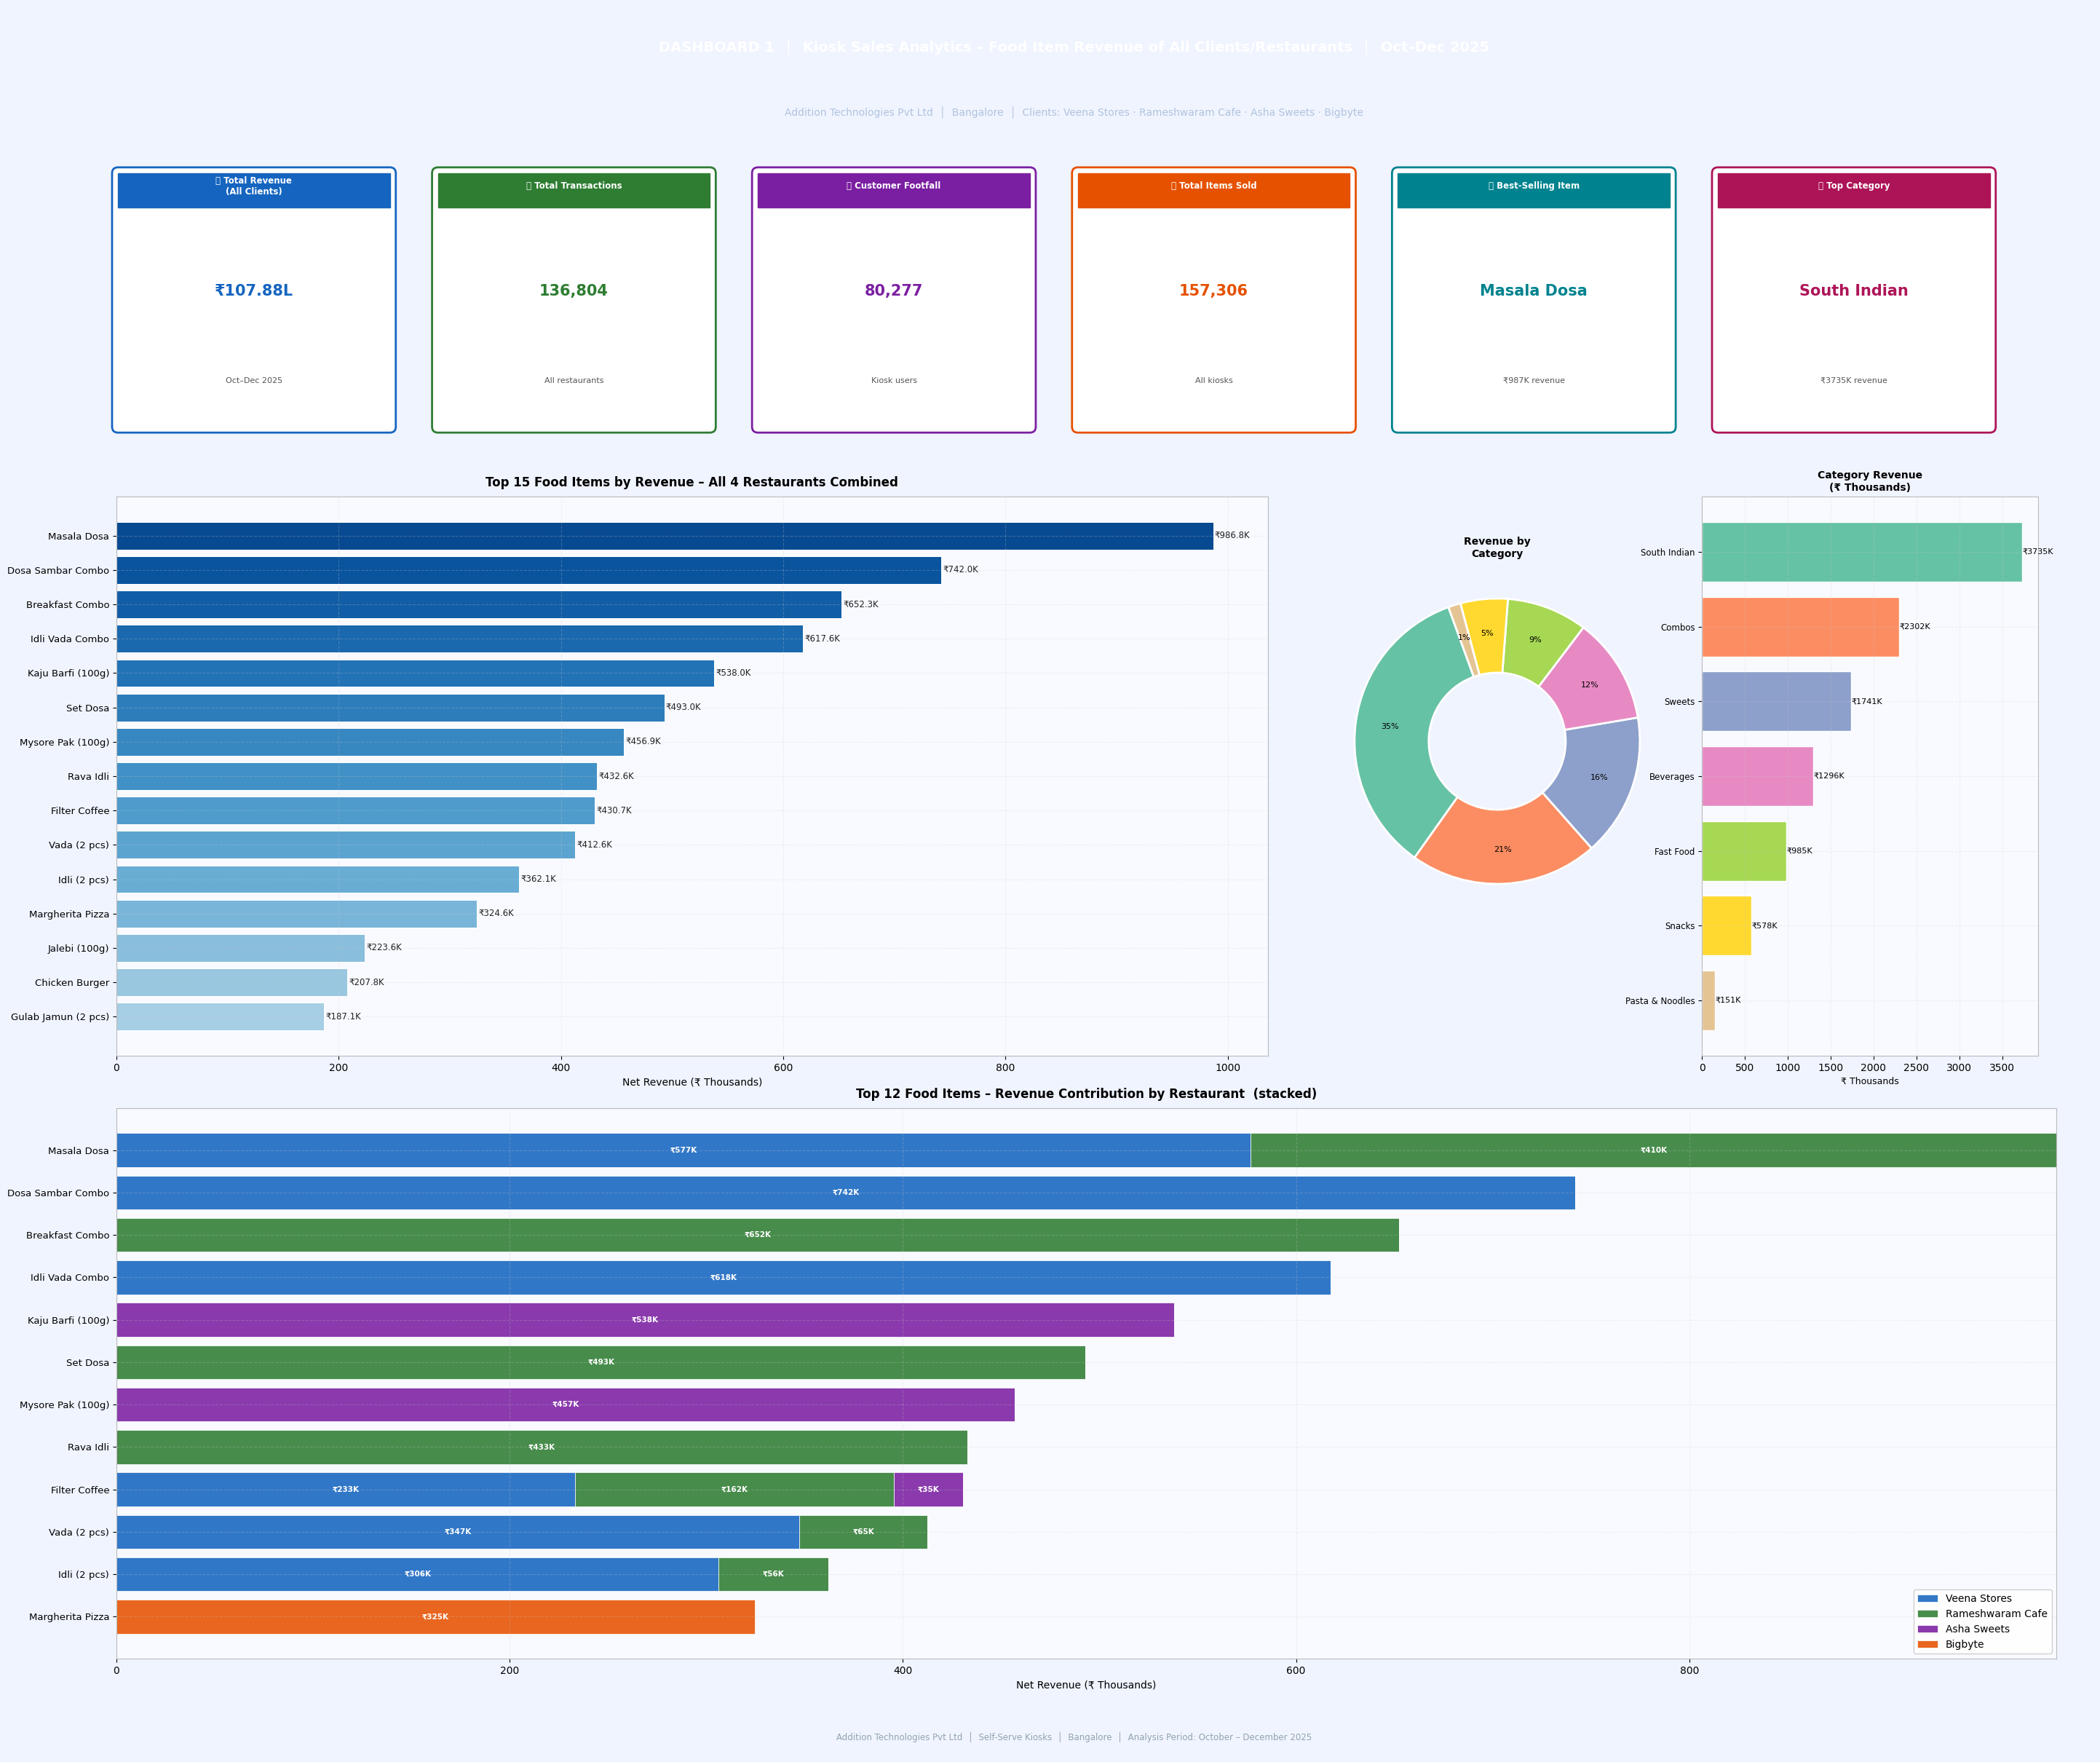

✓ dashboard1_complete.png saved.


In [4]:
# ─── Pre-compute ─────────────────────────────────────────────
total_rev   = df['Net_Sales'].sum()
total_txn   = len(df)
total_ff    = df['Customer_ID'].nunique()
total_items = df['Quantity'].sum()
top_item    = df.groupby('Food_Item')['Net_Sales'].sum().idxmax()
top_item_r  = df.groupby('Food_Item')['Net_Sales'].sum().max()
top_cat     = df.groupby('Category')['Net_Sales'].sum().idxmax()
top_cat_r   = df.groupby('Category')['Net_Sales'].sum().max()

# top-10 items per restaurant (sorted ascending so #1 is at chart top)
rest_top10 = {}
for rest in REST_ORDER:
    s = (df[df['Restaurant'] == rest]
           .groupby('Food_Item')['Net_Sales'].sum()
           .nlargest(10).sort_values(ascending=True))
    rest_top10[rest] = s

# ─── Figure ───────────────────────────────────────────────────────
fig1 = plt.figure(figsize=(28, 27), facecolor=DASH_BG)

# Title banner
draw_title_banner(
    fig1,
    title_text='DASHBOARD 1  │  Kiosk Sales Analytics – Food Item Revenue of All Clients / Restaurants  │  Oct–Dec 2025',
    subtitle_text='Addition Technologies Pvt Ltd  │  Bangalore  │  Clients: Veena Stores  ·  Rameshwaram Cafe  ·  Asha Sweets  ·  Bigbyte',
    y_top=0.940, title_h=0.062, sub_h=0.028
)

# KPI row
kpi_defs = [
    ('💰 Total Revenue\n(All Clients)',  f'₹{total_rev/1e5:.2f}L',  'Oct–Dec 2025',    '#1565C0'),
    ('🧾 Total Transactions',             f'{total_txn:,}',           'All restaurants', '#2E7D32'),
    ('👣 Customer Footfall',              f'{total_ff:,}',            'Kiosk users',     '#7B1FA2'),
    ('📦 Total Items Sold',               f'{total_items:,}',         'All kiosks',      '#E65100'),
    ('🥇 Best-Selling Item',              top_item,                   f'₹{top_item_r/1e3:.0f}K rev', '#00838F'),
    ('🏅 Top Category',                   top_cat,                    f'₹{top_cat_r/1e3:.0f}K rev', '#AD1457'),
]
kw = 0.145; kg = 0.012; kx0 = 0.025
for i, (t, v, s, c) in enumerate(kpi_defs):
    ax = fig1.add_axes([kx0 + i*(kw+kg), 0.762, kw, 0.148])
    kpi_card(ax, t, v, s, accent=c)

# Section label
lax = fig1.add_axes([0.0, 0.722, 1.0, 0.030])
lax.set_facecolor('#1A3A5C')
lax.text(0.5, 0.5, 'TOP FOOD ITEMS BY REVENUE  —  Per Restaurant  │  Oct–Dec 2025',
         ha='center', va='center', fontsize=13, fontweight='bold',
         color='#FFD700', transform=lax.transAxes)
lax.axis('off')

# 2x2 restaurant charts
chart_pos = [
    ('Veena Stores',     0.025, 0.400),
    ('Rameshwaram Cafe', 0.527, 0.400),
    ('Asha Sweets',      0.025, 0.060),
    ('Bigbyte',          0.527, 0.060),
]
CHART_W = 0.450; CHART_H = 0.315

for rest, cx, cy in chart_pos:
    clr  = REST_COLORS[rest]
    data = rest_top10[rest]
    items = data.index.tolist()
    vals  = data.values / 1000
    cax   = fig1.add_axes([cx, cy, CHART_W, CHART_H])
    cax.set_facecolor('#F5F8FF')
    n = len(items)
    rgb = plt.cm.colors.to_rgb(clr)
    bar_colors = [(rgb[0]*a+1*(1-a), rgb[1]*a+1*(1-a), rgb[2]*a+1*(1-a))
                  for a in np.linspace(0.35, 0.92, n)]
    bar_colors[-1] = clr
    bars = cax.barh(items, vals, color=bar_colors, edgecolor='white', linewidth=0.8)
    bars[-1].set_edgecolor(GOLD); bars[-1].set_linewidth(2.5)
    for bar, val in zip(bars, vals):
        cax.text(bar.get_width() + max(vals)*0.015,
                 bar.get_y() + bar.get_height()/2,
                 f'₹{val:.1f}K', va='center', fontsize=9, color='#222',
                 fontweight='bold' if bar == bars[-1] else 'normal')
    cax.set_title(f'{rest}  —  Top 10 Food Items by Revenue',
                  fontsize=12, fontweight='bold', color=clr, pad=10, loc='left')
    cax.set_xlabel('Net Revenue (₹ Thousands)', fontsize=9.5, color='#444')
    cax.tick_params(axis='y', labelsize=9.5)
    cax.tick_params(axis='x', labelsize=9)
    cax.set_xlim(right=max(vals)*1.22)
    for sp in cax.spines.values(): sp.set_visible(True); sp.set_linewidth(0.6); sp.set_color('#CCCCCC')
    cax.spines['left'].set_color(clr); cax.spines['left'].set_linewidth(4)

# Footer
fax = fig1.add_axes([0.0, 0.0, 1.0, 0.022])
fax.set_facecolor(BRAND_BG)
fax.text(0.5, 0.5,
         'Addition Technologies Pvt Ltd  │  Self-Serve Kiosks  │  Bangalore  │  Analysis Period: October – December 2025',
         ha='center', va='center', fontsize=9, color='#90A4AE', transform=fax.transAxes)
fax.axis('off')

fig1.savefig('dashboard1_complete.png', dpi=150, bbox_inches='tight', facecolor=DASH_BG)
plt.show()
print('✓ dashboard1_complete.png saved.')

---
# 📈 Dashboard 2
## Sales Comparison of All 4 Clients
### October – December 2025

> Single composite image: **highly-visible title banner** + **4 per-restaurant KPI cards** + Monthly trend line + Grouped bar + Revenue donut + Payment mode stacked bar + Footfall trend


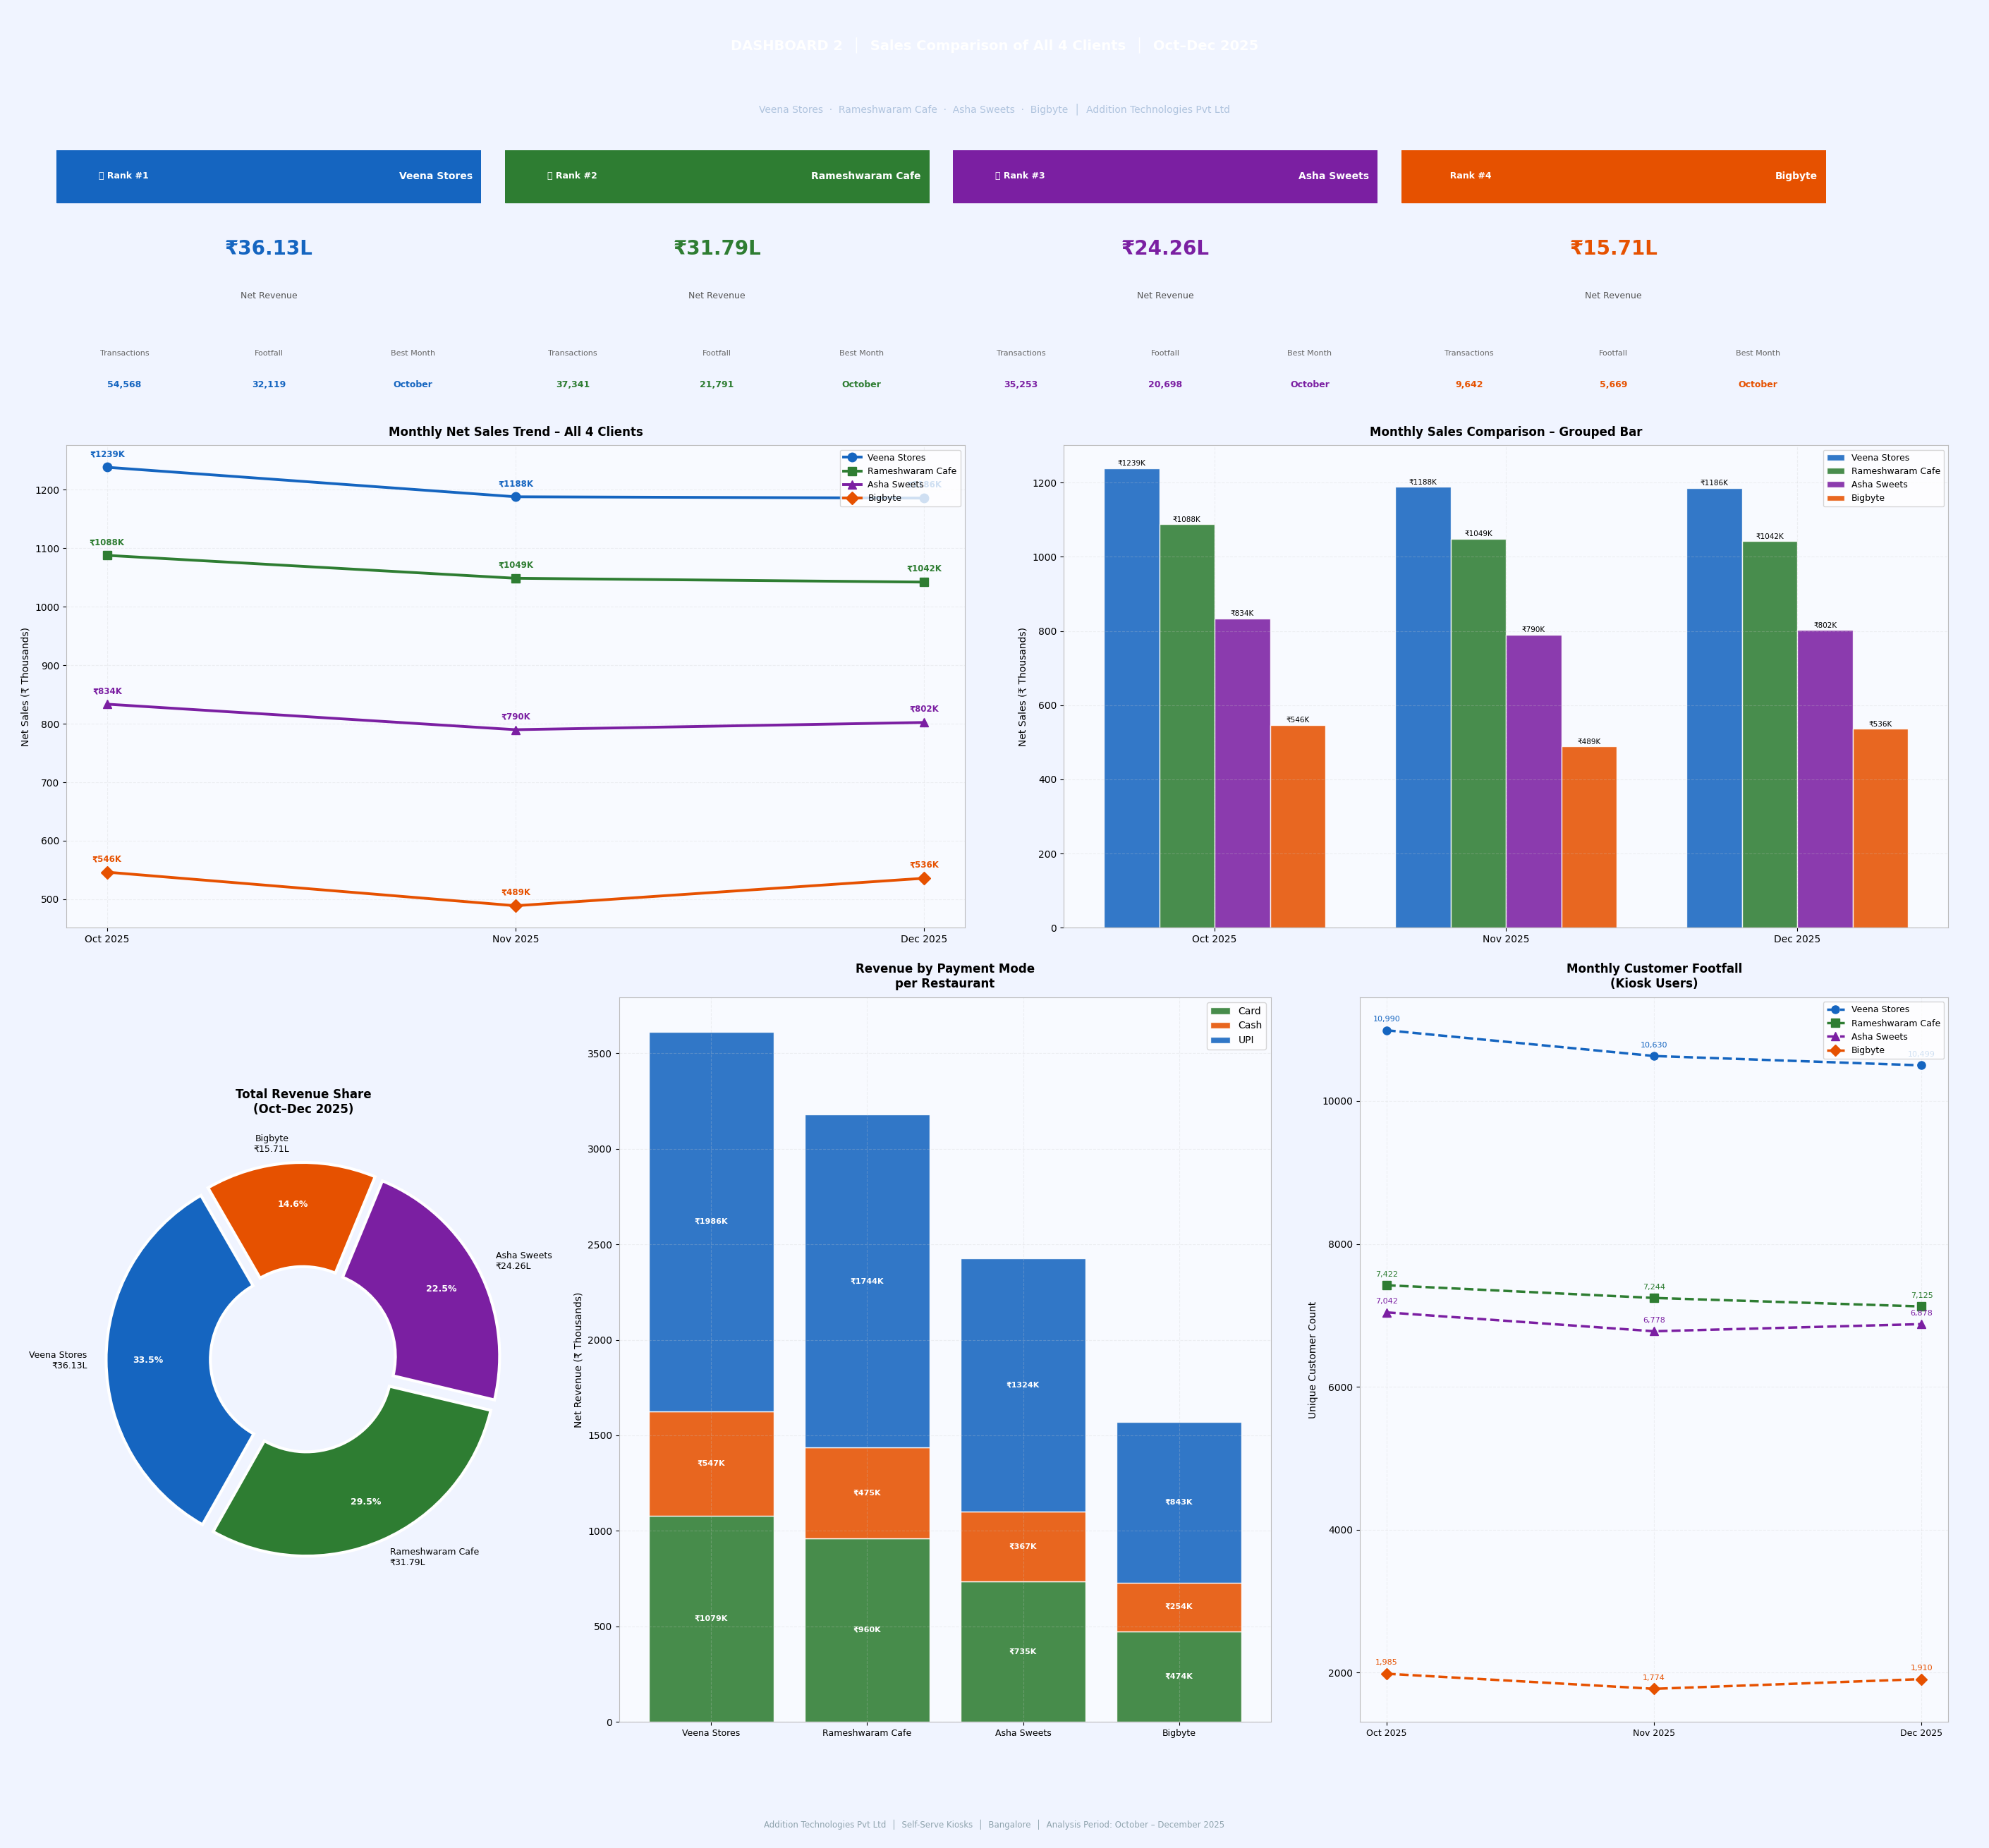

✓ dashboard2_complete.png saved.


In [5]:
# ─── Pre-compute ─────────────────────────────────────────────
rest_agg = (df.groupby('Restaurant')
              .agg(Revenue=('Net_Sales','sum'),
                   Transactions=('Transaction_ID','count'),
                   Footfall=('Customer_ID','nunique'))
              .reindex(REST_ORDER))

monthly = (df.groupby(['Month','Restaurant'])['Net_Sales']
             .sum().unstack('Restaurant').reindex(columns=REST_ORDER) / 1000)

footfall_m = (df.groupby(['Month','Restaurant'])['Customer_ID']
                .nunique().unstack('Restaurant').reindex(columns=REST_ORDER))

pay_rest = (df.groupby(['Restaurant','Payment_Mode'])['Net_Sales']
              .sum().unstack('Payment_Mode').reindex(REST_ORDER).fillna(0) / 1000)

total_by_rest = rest_agg['Revenue']

best_month = (df.groupby(['Restaurant','Month'])['Net_Sales']
                .sum().groupby('Restaurant').idxmax()
                .map(lambda x: x[1].replace(' 2025','')))

# ─── Figure ──────────────────────────────────────────────────────
fig2 = plt.figure(figsize=(28, 27), facecolor=DASH_BG)

draw_title_banner(
    fig2,
    title_text='DASHBOARD 2  │  Sales Comparison of All 4 Clients  │  Oct–Dec 2025',
    subtitle_text='Veena Stores  ·  Rameshwaram Cafe  ·  Asha Sweets  ·  Bigbyte  │  Addition Technologies Pvt Ltd  │  Bangalore',
    y_top=0.940, title_h=0.062, sub_h=0.028
)

# 4 per-restaurant KPI cards
rank_labels = {1:'🥇 Rank #1', 2:'🥈 Rank #2', 3:'🥉 Rank #3', 4:'  Rank #4'}
kw2=0.215; kg2=0.012; kx02=0.025
for i, rest in enumerate(REST_ORDER):
    clr = REST_COLORS[rest]
    rev = rest_agg.loc[rest,'Revenue']
    txn = rest_agg.loc[rest,'Transactions']
    ff  = rest_agg.loc[rest,'Footfall']
    bm  = best_month.get(rest,'-')
    ax  = fig2.add_axes([kx02+i*(kw2+kg2), 0.770, kw2, 0.148])
    ax.set_facecolor('#F8FAFF')
    ax.add_patch(plt.Rectangle((0,0.79),1.0,0.21,color=clr,transform=ax.transAxes,zorder=3))
    ax.text(0.08,0.900,rank_labels[i+1],ha='left',va='center',fontsize=9.5,
            color='white',fontweight='bold',transform=ax.transAxes,zorder=4)
    ax.text(0.97,0.900,rest,ha='right',va='center',fontsize=11,
            color='white',fontweight='bold',transform=ax.transAxes,zorder=4)
    ax.text(0.5,0.60,f'₹{rev/1e5:.2f}L',ha='center',va='center',fontsize=22,
            fontweight='bold',color=clr,transform=ax.transAxes)
    ax.text(0.5,0.42,'Net Revenue',ha='center',va='center',fontsize=9.5,
            color='#555',transform=ax.transAxes)
    for j,(label,val) in enumerate([(f'{txn:,}','Transactions'),(f'{ff:,}','Footfall'),(bm,'Best Month')]):
        xp = 0.16+j*0.34
        ax.text(xp,0.22,val,  ha='center',va='center',fontsize=8,  color='#666',transform=ax.transAxes)
        ax.text(xp,0.09,label,ha='center',va='center',fontsize=9.5,
                fontweight='bold',color=clr,transform=ax.transAxes)
    for sp in ax.spines.values(): sp.set_edgecolor(clr); sp.set_linewidth(2.5)
    ax.axis('off')

# Monthly trend line
markers=['o','s','^','D']
ax_trend = fig2.add_axes([0.030,0.493,0.450,0.260])
for rest,mkr in zip(REST_ORDER,markers):
    vals=monthly[rest].values
    ax_trend.plot(MONTHS_SHORT,vals,marker=mkr,linewidth=2.8,markersize=9,color=REST_COLORS[rest],label=rest)
    for xi,yv in enumerate(vals):
        ax_trend.annotate(f'₹{yv:.0f}K',(xi,yv),textcoords='offset points',xytext=(0,11),
                          ha='center',fontsize=8.5,color=REST_COLORS[rest],fontweight='bold')
ax_trend.set_title('Monthly Net Sales Trend – All 4 Clients',fontsize=12,fontweight='bold',pad=10)
ax_trend.set_ylabel('Net Sales (₹ Thousands)',fontsize=10)
ax_trend.legend(fontsize=9,loc='upper right')
ax_trend.set_xticks(range(3)); ax_trend.set_xticklabels(MONTHS_SHORT,fontsize=10)
ax_trend.set_facecolor('#F8FAFF')

# Monthly grouped bar
ax_gbar=fig2.add_axes([0.535,0.493,0.448,0.260])
x=np.arange(3); w=0.19; offsets=[-1.5,-0.5,0.5,1.5]
for rest,off in zip(REST_ORDER,offsets):
    vals=monthly[rest].values
    bars=ax_gbar.bar(x+off*w,vals,width=w,label=rest,color=REST_COLORS[rest],alpha=0.88,edgecolor='white')
    for bar in bars:
        ax_gbar.text(bar.get_x()+bar.get_width()/2,bar.get_height()+3,
                     f'₹{bar.get_height():.0f}K',ha='center',va='bottom',fontsize=7.5)
ax_gbar.set_title('Monthly Sales Comparison – Grouped Bar',fontsize=12,fontweight='bold',pad=10)
ax_gbar.set_xticks(x); ax_gbar.set_xticklabels(MONTHS_SHORT,fontsize=10)
ax_gbar.set_ylabel('Net Sales (₹ Thousands)',fontsize=10)
ax_gbar.legend(fontsize=9); ax_gbar.set_facecolor('#F8FAFF')

# Revenue share donut
ax_donut=fig2.add_axes([0.030,0.060,0.240,0.400])
wedges,texts,autos=ax_donut.pie(total_by_rest.values,
    labels=[f'{r}\n₹{v/1e5:.2f}L' for r,v in total_by_rest.items()],
    autopct='%1.1f%%',startangle=120,colors=[REST_COLORS[r] for r in REST_ORDER],
    wedgeprops=dict(width=0.55,edgecolor='white',linewidth=3),
    explode=[0.04]*4,pctdistance=0.78)
for t in texts: t.set_fontsize(9)
for a in autos: a.set_fontsize(9); a.set_fontweight('bold'); a.set_color('white')
ax_donut.set_title('Total Revenue Share\n(Oct–Dec 2025)',fontsize=12,fontweight='bold',pad=10)

# Payment mode stacked bar
ax_pay=fig2.add_axes([0.308,0.060,0.330,0.400])
pay_cols=pay_rest.columns.tolist()
pay_colors={'UPI':'#1565C0','Card':'#2E7D32','Cash':'#E65100'}
bottom_arr=np.zeros(len(REST_ORDER))
for pm in pay_cols:
    vals=pay_rest[pm].values
    bars=ax_pay.bar(REST_ORDER,vals,bottom=bottom_arr,label=pm,
                    color=pay_colors.get(pm,'#999'),alpha=0.88,edgecolor='white')
    for b,bv,bot in zip(bars,vals,bottom_arr):
        if bv>30: ax_pay.text(b.get_x()+b.get_width()/2,bot+bv/2,
                              f'₹{bv:.0f}K',ha='center',va='center',fontsize=8,fontweight='bold',color='white')
    bottom_arr+=vals
ax_pay.set_title('Revenue by Payment Mode\nper Restaurant',fontsize=12,fontweight='bold',pad=10)
ax_pay.set_ylabel('Net Revenue (₹ Thousands)',fontsize=10)
ax_pay.legend(fontsize=10,loc='upper right'); ax_pay.set_facecolor('#F8FAFF')
ax_pay.tick_params(axis='x',labelsize=9)

# Footfall trend
ax_ff=fig2.add_axes([0.685,0.060,0.298,0.400])
for rest,mkr in zip(REST_ORDER,markers):
    vals=footfall_m[rest].values
    ax_ff.plot(MONTHS_SHORT,vals,marker=mkr,linewidth=2.5,markersize=8,
               color=REST_COLORS[rest],label=rest,linestyle='--')
    for xi,yv in enumerate(vals):
        ax_ff.annotate(f'{yv:,}',(xi,yv),textcoords='offset points',xytext=(0,9),
                       ha='center',fontsize=8,color=REST_COLORS[rest])
ax_ff.set_title('Monthly Customer Footfall\n(Kiosk Users)',fontsize=12,fontweight='bold',pad=10)
ax_ff.set_ylabel('Unique Customer Count',fontsize=10)
ax_ff.legend(fontsize=9,loc='upper right')
ax_ff.set_xticks(range(3)); ax_ff.set_xticklabels(MONTHS_SHORT,fontsize=9)
ax_ff.set_facecolor('#F8FAFF')

# Footer
fax2=fig2.add_axes([0.0,0.0,1.0,0.022])
fax2.set_facecolor(BRAND_BG)
fax2.text(0.5,0.5,
          'Addition Technologies Pvt Ltd  │  Self-Serve Kiosks  │  Bangalore  │  Analysis Period: October – December 2025',
          ha='center',va='center',fontsize=9,color='#90A4AE',transform=fax2.transAxes)
fax2.axis('off')

fig2.savefig('dashboard2_complete.png', dpi=150, bbox_inches='tight', facecolor=DASH_BG)
plt.show()
print('✓ dashboard2_complete.png saved.')

---
## Power BI Import Guide

1. Open **Power BI Desktop** → **Get Data → Text/CSV** → `Kiosks_Sales_PowerBI_Ready.csv`
2. Set `Date` → **Date**; `Order_DateTime` → **Date/Time**
3. Sort `Month` column by `Month_Num`
4. Add slicers on **Month** for Oct / Nov / Dec filtering

### Dashboard 1 page – Kiosk Sales Analytics: Food Item Revenue
| Visual | Field | Values |
|--------|-------|--------|
| 6 KPI Cards | — | Total Revenue · Transactions · Footfall · Items Sold · Best Item · Top Category |
| Horizontal Bar (Top 15) | Food_Item | Sum Net_Sales (all restaurants) |
| Donut + Bar | Category | Sum Net_Sales |
| 100% Stacked Bar | Food_Item | Net_Sales, Legend=Restaurant (Top 12) |

### Dashboard 2 page – Sales Comparison of All 4 Clients
| Visual | Field | Values |
|--------|-------|--------|
| 4 KPI Cards | Restaurant | Revenue · Transactions · Footfall · Best Month |
| Line Chart | Month | Net_Sales, Legend=Restaurant |
| Grouped Bar | Month | Net_Sales, Legend=Restaurant |
| Donut Chart | Restaurant | Net_Sales |
| Stacked Bar | Restaurant | Net_Sales, Legend=Payment_Mode |
| Dashed Line | Month | Count Customer_ID, Legend=Restaurant |
